# LeR Plots

In [1]:
# Import LeR
from ler.rates import LeR

# Initialize LeR with default settings
# npool: number of parallel processes for sampling
ler = LeR(
    npool=6,
    event_type='BBH',
    spin_zeros=False,
    spin_precession=True,
    snr_method='interpolation_aligned_spins',
    snr_recalculation=True,
    snr_recalculation_range=[5, 15],
    waveform_approximant='IMRPhenomXPHM',  # Waveform model
)


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : axis_ratio_rayleigh
axis_ratio_rayleigh interpolator will be loaded from ./interpolator_json/a

## Unlensed 

In [2]:
detectable_rate_unlensed, unlensed_param_detectable = ler.selecting_n_unlensed_detectable_events(
    size=10000,                          # Target number of detectable events
    batch_size=50000,                   # Events per batch
    stopping_criteria=dict(
        relative_diff_percentage=0.5,    # Stop when rate change < 0.5%
        number_of_last_batches_to_check=4  # Check last 4 batches for convergence
    ),
    pdet_threshold=0.5,                  # Probability threshold for detection
    resume=True,                         # Resume from previous state if available
    output_jsonfile='unlensed_detectable_BBH_O4.json',  # Output file for detectable events
    meta_data_file='meta_unlensed_BBH_O4.json', # Store metadata (rates per batch)
    pdet_type='boolean',                 # Detection type: 'boolean' or 'float'
    trim_to_size=False,                  # Keep all events found until convergence
)

print(f"\n=== Unlensed N-Event Sampling Results ===")
print(f"Detectable event rate: {detectable_rate_unlensed:.4e} events per year")
print(f"Total detectable events collected: {len(unlensed_param_detectable['zs'])}")

stopping criteria set to when relative difference of total rate for the last 4 cumulative batches is less than 0.5%.
sample collection will stop when the stopping criteria is met and number of detectable events exceeds the specified size.
Number of collected events does not match with the number of events in the meta data file.
collected number of detectable events =  10002


100%|██████████████████████████████████████████████████████████| 1189/1189 [00:02<00:00, 432.48it/s]


ValueError: The dictionaries have different keys.

In [8]:
unlensed_param = ler.unlensed_cbc_statistics(size=5000, resume=True, output_jsonfile='unlensed_BBH_O4.json')

unlensed params will be stored in ./ler_data/unlensed_BBH_O4.json
resuming from ./ler_data/unlensed_BBH_O4.json
unlensed parameters already sampled.
saving all unlensed parameters in ./ler_data/unlensed_BBH_O4.json 


In [6]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ler.utils import get_param_from_json
import matplotlib as mpl
from matplotlib.lines import Line2D

# without sns, with only corner plots
import corner
import matplotlib.lines as mlines

# Load data
param = get_param_from_json('./ler_data/unlensed_BBH_O4.json')
param_detectable = get_param_from_json('./ler_data/unlensed_detectable_BBH_O4.json')

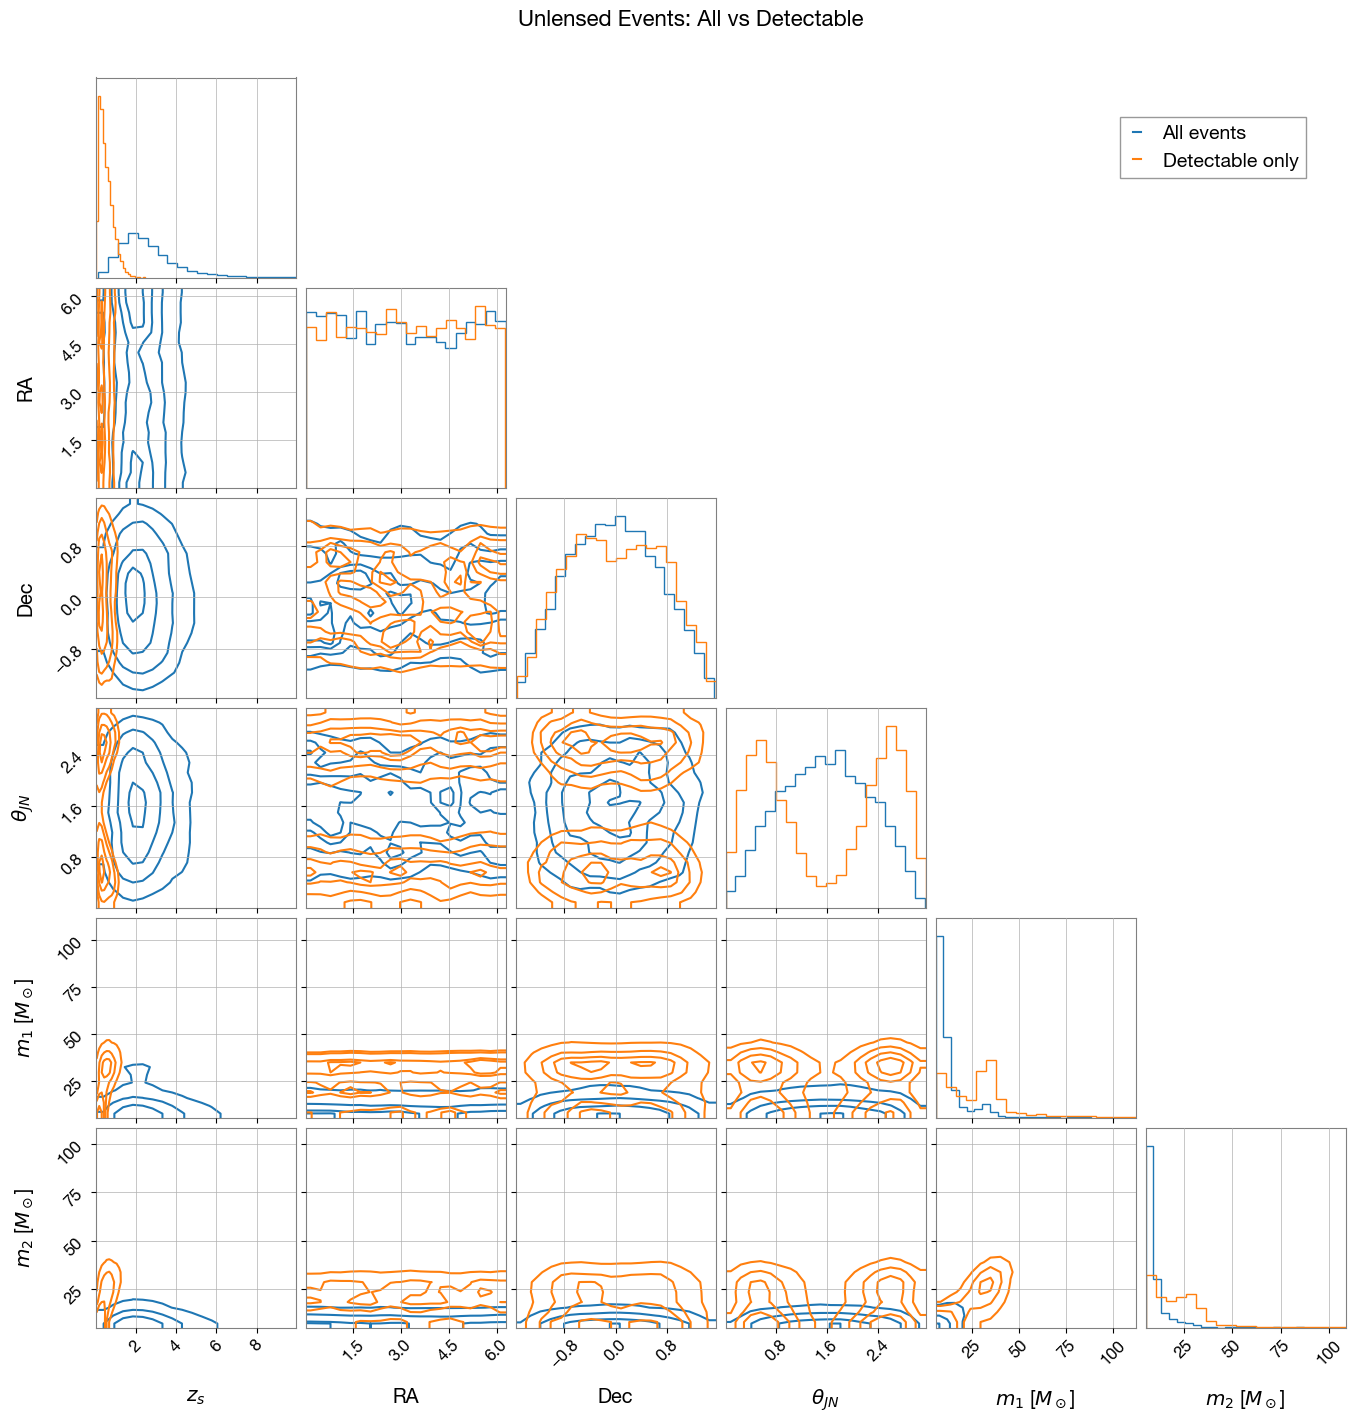

In [4]:
# Parameters to compare
param_names = ['zs', 'ra', 'dec', 'theta_jn', 'mass_1_source', 'mass_2_source']
labels = ['$z_s$', 'RA', 'Dec', r'$\theta_{JN}$', '$m_1$ [$M_\odot$]', '$m_2$ [$M_\odot$]']

# Prepare data for corner plot
samples_all = np.stack([param[p] for p in param_names], axis=1)
samples_detectable = np.stack([param_detectable[p] for p in param_names], axis=1)

# Create corner plot for all events
fig = corner.corner(
    samples_all, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Overlay detectable events
corner.corner(
    samples_detectable, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    fig=fig, 
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Add legend
blue_line = mlines.Line2D([], [], color='C0', label='All events')
orange_line = mlines.Line2D([], [], color='C1', label='Detectable only')
fig.legend(handles=[blue_line, orange_line], loc='upper right', 
           bbox_to_anchor=(0.95, 0.95), fontsize=14)
fig.suptitle('Unlensed Events: All vs Detectable', fontsize=16, y=1.02)

plt.show()

size : 5000


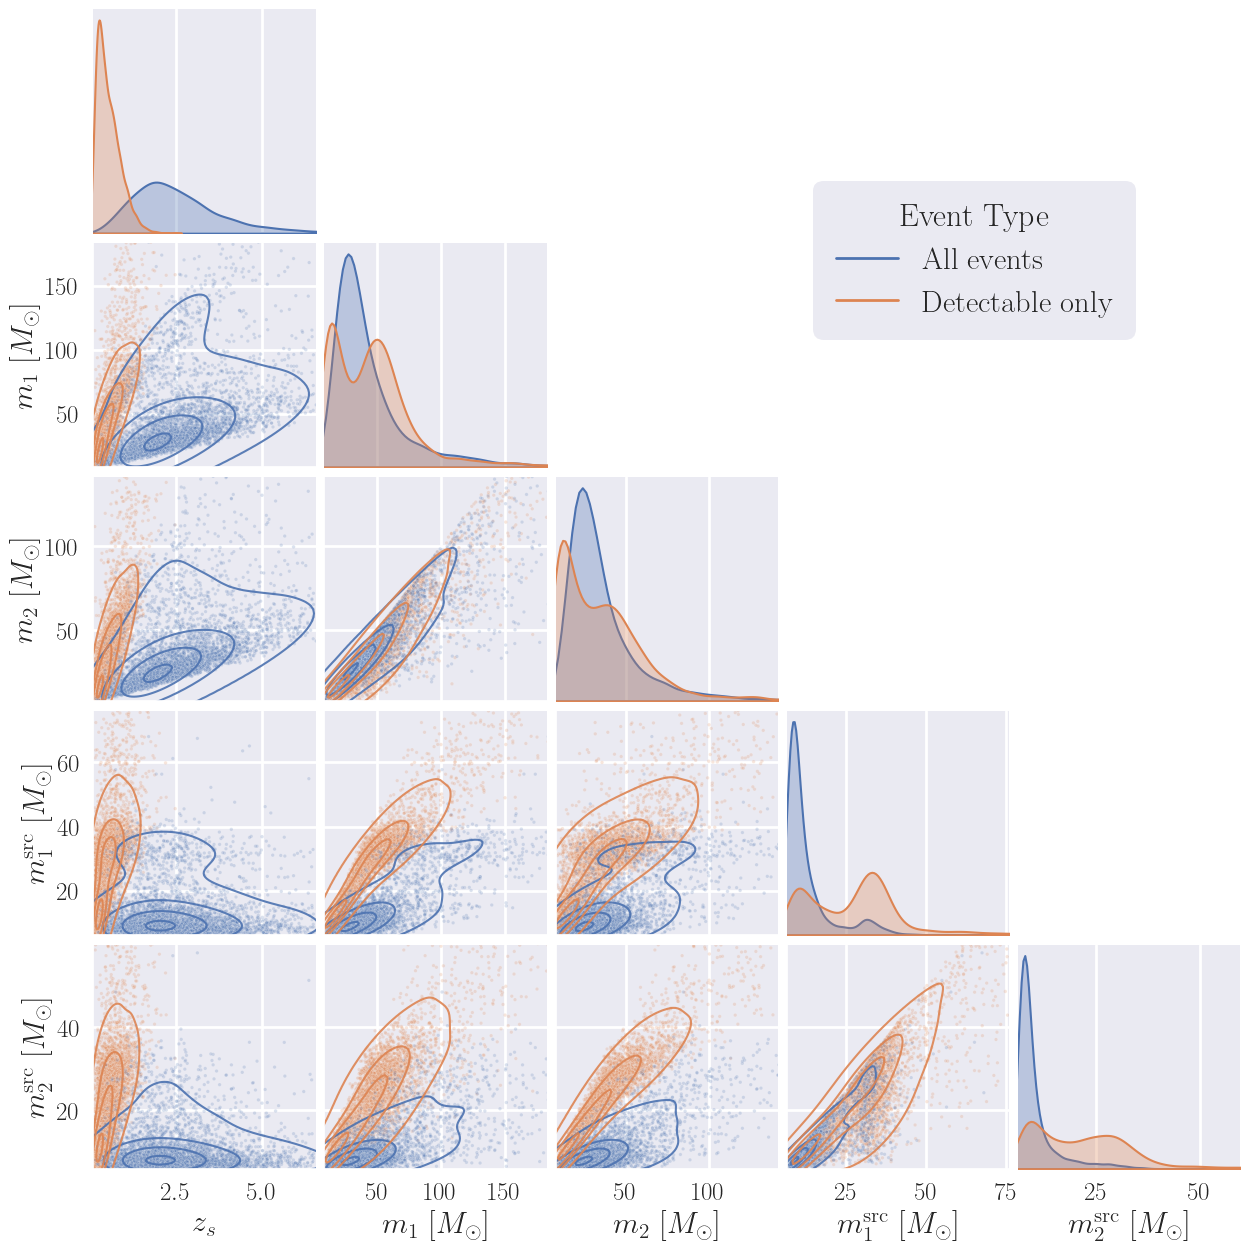

In [7]:
# Reset to defaults (optional but good if you've been tweaking rcParams a lot)
mpl.rcParams.update(mpl.rcParamsDefault)
LIGHT_BG = "#EAEAF2"

# --- Seaborn grey background + white grid ---
sns.set_theme(
    style="darkgrid",   # grey background
    context="notebook",
    rc={
        # background
        "axes.facecolor": LIGHT_BG,   # seaborn-like grey
        "figure.facecolor": "white",
        # grid (white lines)
        "axes.grid": True,
        "grid.color": "white",
        "grid.linestyle": "-",
        "grid.linewidth": 2.0,
        "grid.alpha": 1.0,
        # keep grid behind artists
        "axes.axisbelow": True,
        # ticks (optional, helps readability on grey bg)
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "custom",
    "savefig.dpi": 150,
})

# Parameters to compare
param_names = ['zs', 'mass_1', 'mass_2', 'mass_1_source', 'mass_2_source']
labels = ['$z_s$', '$m_1$ [$M_\\odot$]', '$m_2$ [$M_\\odot$]', '$m_1^{\\rm src}$ [$M_\\odot$]', '$m_2^{\\rm src}$ [$M_\\odot$]']

size = 5000
size = len(param_detectable[param_names[0]]) if len(param_detectable[param_names[0]]) < size else size

# Create DataFrames
indices = np.random.choice(len(param_detectable[param_names[0]]), size=size, replace=False)
df_detectable = pd.DataFrame({label: param_detectable[name][indices] for name, label in zip(param_names, labels)})
df_detectable['Event Type'] = 'Detectable only'

print(f"size : {size}")

indices = np.random.choice(len(param[param_names[0]]), size=size, replace=False)
df_all = pd.DataFrame({label: param[name][indices] for name, label in zip(param_names, labels)})
df_all['Event Type'] = 'All events'

# Combine DataFrames
df_combined = pd.concat([df_detectable, df_all], ignore_index=True)

# Calculate 1st and 99th percentiles for each parameter to set limits
percentile_limits = {}
for label in labels:
    lower = np.percentile(df_combined[label], 1.0)
    upper = np.percentile(df_combined[label], 99.0)
    # Add some padding (5% of range)
    range_pad = (upper - lower) * 0.0
    percentile_limits[label] = (lower - range_pad, upper + range_pad)

# Create pairplot with both scatter and contour (KDE) for 2D plots
# First, make the scatter pairplot with smaller point size
pairplot_scatter = sns.pairplot(
    df_combined,
    hue='Event Type',
    palette={'All events': 'C0', 'Detectable only': 'C1'},
    corner=True,
    kind='scatter',
    plot_kws=dict(marker=".", alpha=0.2, s=25),  # s=25 for larger points
    diag_kind='kde',
    diag_kws={'alpha': 0.3, 'linewidth': 1.5}
)

contour_levels=np.sort(np.array([10, 40, 68, 95])/100)
# Overlay KDE contours on the lower triangle
for i, row_label in enumerate(labels):
    for j, col_label in enumerate(labels):
        if i > j:
            ax = pairplot_scatter.axes[i, j]
            for event_type, color in zip(['All events', 'Detectable only'], ['C0', 'C1']):
                subset = df_combined[df_combined['Event Type'] == event_type]
                sns.kdeplot(
                    x=subset[col_label],
                    y=subset[row_label],
                    ax=ax,
                    levels=contour_levels,
                    color=color,
                    alpha=0.9,
                    linewidths=1.5,
                    bw_adjust=1.8,
                    fill=False
                )
            ax.set_xlim(percentile_limits[col_label])
            ax.set_ylim(percentile_limits[row_label])
        elif i == j:
            ax = pairplot_scatter.axes[i, j]
            ax.set_xlim(percentile_limits[row_label])

# Remove the default legend created by seaborn
if pairplot_scatter._legend is not None:
    pairplot_scatter._legend.remove()

# Custom legend with line handles instead of points
line_handles = [
    Line2D([0], [0], color='C0', lw=2, label='All events'),
    Line2D([0], [0], color='C1', lw=2, label='Detectable only')
]
leg = pairplot_scatter.fig.legend(
    handles=line_handles,
    title="Event Type",
    loc='upper right',
    bbox_to_anchor=(0.80, 0.85),
    fontsize=22,
    title_fontsize=23,
    frameon=True
)
leg.get_title().set_weight("bold")
frame = leg.get_frame()
frame.set_facecolor("#EAEAF2")
frame.set_edgecolor("none")
frame.set_linewidth(0.6)
frame.set_alpha(1.0)
frame.set_boxstyle("round,pad=0.35")

# Increase axis label font size
for ax in pairplot_scatter.fig.axes:
    ax.set_facecolor(LIGHT_BG)
    # ax.grid(True, color="black", linestyle='--', linewidth=1.0, alpha=0.1)
    ax.xaxis.label.set_size(22)
    ax.yaxis.label.set_size(22)
    ax.tick_params(labelsize=18)

pairplot_scatter.fig.savefig("Unlensed_Events.png", bbox_inches="tight", dpi=300)
plt.show()
# 30s

## Lensed 

In [1]:
# Import LeR
from ler.rates import LeR

# Initialize LeR with default settings
# npool: number of parallel processes for sampling
ler = LeR(
    npool=6,
    event_type='BBH',
    spin_zeros=False,
    spin_precession=True,
    snr_method='interpolation_aligned_spins',
    snr_recalculation=True,
    snr_recalculation_range=[5, 15],
    waveform_approximant='IMRPhenomXPHM',  # Waveform model
)


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : axis_ratio_rayleigh
axis_ratio_rayleigh interpolator will be loaded from ./interpolator_json/a

In [2]:
lensed_param = ler.lensed_cbc_statistics(size=5000, batch_size=5000, resume=True, output_jsonfile='lensed_BBH_O4.json')

lensed params will be stored in ./ler_data/lensed_BBH_O4.json
removing ./ler_data/lensed_BBH_O4.json if it exists
resuming from ./ler_data/lensed_BBH_O4.json
Batch no. 1
sampling lensed params...
sampling lens parameters with sample_all_routine_epl_shear_sl...
solving lens equations...


100%|█████████████████████████████████████████████████████████| 5000/5000 [00:01<00:00, 3981.02it/s]


calculating pdet...
Recalculating SNR for 137 out of 5000 samples in the SNR range of 5 to 15


100%|████████████████████████████████████████████████████████████| 137/137 [00:00<00:00, 422.43it/s]


Recalculating SNR for 49 out of 4758 samples in the SNR range of 5 to 15


...

Recalculating SNR for 17 out of 234 samples in the SNR range of 5 to 15


100%|██████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 106.14it/s]


Recalculating SNR for 4 out of 217 samples in the SNR range of 5 to 15


100%|█████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 28.95it/s]

lensed parameters already sampled.
saving all lensed parameters in ./ler_data/lensed_BBH_O4.json 


In [4]:
# Generate a large sample of all lensed events for comparison
lensed_param_intrinsic = ler.sample_all_routine_epl_shear_intrinsic(size=5000)

print(f"Total lensed events sampled: {len(lensed_param_intrinsic['zs'])}")

# save to file
from ler.utils import append_json
append_json(ler.ler_directory+'/lensed_intrinsic_BBH_O4.json', lensed_param_intrinsic, replace=True);

Total lensed events sampled: 5000


In [2]:
detectable_rate_lensed, lensed_param_detectable = ler.selecting_n_lensed_detectable_events(
    size=10000,                          # Target number of detectable events
    batch_size=50000,                   # Events per batch
    stopping_criteria=dict(
        relative_diff_percentage=0.5,    # Stop when rate change < 0.5%
        number_of_last_batches_to_check=4  # Check last 4 batches for convergence
    ),
    pdet_threshold=[0.5, 0.5],
    num_img=[1, 1],
    resume=True,
    pdet_type="boolean",
    output_jsonfile="lensed_detectable_BBH_O4.json",
    meta_data_file="meta_unlensed_BBH_O4.json",
    trim_to_size=False,
    nan_to_num=True,
)

stopping criteria set to when relative difference of total rate for the last 4 cumulative batches is less than 0.5%.
sample collection will stop when the stopping criteria is met and number of detectable events exceeds the specified size.
Resuming from 10002 detectable events.
percentage difference of total rate for the last 4 cumulative batches = [0.0147988  0.0400797  0.07544343 0.        ]
stopping criteria of rate relative difference of 0.5% for the last 4 cumulative batches reached.
Given size=10000 reached

Stopping criteria met. There will be no more samples collected.
collected number of detectable events =  10002
storing detectable lensed params in ./ler_data/lensed_detectable_BBH_O4.json
storing meta data in ./ler_data/meta_unlensed_BBH_O4.json


In [3]:
detectable_rate_lensed, lensed_param_detectable = ler.selecting_n_lensed_detectable_events(
    size=5000,                          # Target number of detectable events
    batch_size=50000,                   # Events per batch
    stopping_criteria=dict(
        relative_diff_percentage=0.5,    # Stop when rate change < 0.5%
        number_of_last_batches_to_check=4  # Check last 4 batches for convergence
    ),
    pdet_threshold=[0.5, 0.5],
    num_img=[1, 1],
    resume=True,
    pdet_type="boolean",
    output_jsonfile="lensed_detectable_BBH_O4_2.json",
    meta_data_file="meta_unlensed_BBH_O4_2.json",
    trim_to_size=False,
    nan_to_num=True,
)

stopping criteria set to when relative difference of total rate for the last 4 cumulative batches is less than 0.5%.
sample collection will stop when the stopping criteria is met and number of detectable events exceeds the specified size.
Resuming from 539 detectable events.
percentage difference of total rate for the last 4 cumulative batches = [0.43290043 0.25974026 0.21926126 0.        ]
stopping criteria of rate relative difference of 0.5% for the last 4 cumulative batches reached.
collected number of detectable events =  539


100%|██████████████████████████████████████████████████████████████| 38/38 [00:00<00:00, 219.95it/s]


collected number of detectable events (batch) =  37
collected number of detectable events (cumulative) =  576
total number of events =  650000
total rate (yr^-1): 0.10038629456506681
percentage difference of total rate for the last 4 cumulative batches = [1.11111111 1.15214646 1.3744213  0.        ]


100%|██████████████████████████████████████████████████████████████| 42/42 [00:00<00:00, 230.95it/s]


collected number of detectable events (batch) =  55
collected number of detectable events (cumulative) =  631
total number of events =  700000
total rate (yr^-1): 0.10211666348180097
percentage difference of total rate for the last 4 cumulative batches = [0.56187869 0.34337031 1.69450201 0.        ]


...

collected number of detectable events (batch) =  53
collected number of detectable events (cumulative) =  4910
total number of events =  5700000
total rate (yr^-1): 0.09758249850889705
percentage difference of total rate for the last 4 cumulative batches = [0.20476689 0.1422025  0.20402646 0.        ]
stopping criteria of rate relative difference of 0.5% for the last 4 cumulative batches reached.


100%|██████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 236.86it/s]


collected number of detectable events (batch) =  49
collected number of detectable events (cumulative) =  4959
total number of events =  5750000
total rate (yr^-1): 0.09769932445238771
percentage difference of total rate for the last 4 cumulative batches = [0.26160948 0.32335951 0.11957702 0.        ]
stopping criteria of rate relative difference of 0.5% for the last 4 cumulative batches reached.


100%|██████████████████████████████████████████████████████████████| 49/49 [00:00<00:00, 276.05it/s]


collected number of detectable events (batch) =  50
collected number of detectable events (cumulative) =  5009
total number of events =  5800000
total rate (yr^-1): 0.09783366773218176
percentage difference of total rate for the last 4 cumulative batches = [0.46023353 0.25673087 0.13731804 0.        ]
stopping criteria of rate relative difference of 0.5% for the last 4 cumulative batches reached.
Given size=5000 reached

storing detectable lensed params in ./ler_data/lensed_detectable_BBH_O4_2.json
storing meta data in ./ler_data/meta_unlensed_BBH_O4_2.json


In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ler.utils import get_param_from_json
import matplotlib as mpl
from matplotlib.lines import Line2D

# without sns, with only corner plots
import corner
import matplotlib.lines as mlines

# Load data
unlensed_param = get_param_from_json('./ler_data/unlensed_BBH_O4.json')
unlensed_param_detectable = get_param_from_json('./ler_data/unlensed_detectable_BBH_O4.json')
lensed_param = get_param_from_json('./ler_data/lensed_BBH_O4.json')
lensed_param_detectable = get_param_from_json('./ler_data/lensed_detectable_BBH_O4_2.json')
lensed_param_intrinsic = get_param_from_json('./ler_data/lensed_intrinsic_BBH_O4.json')

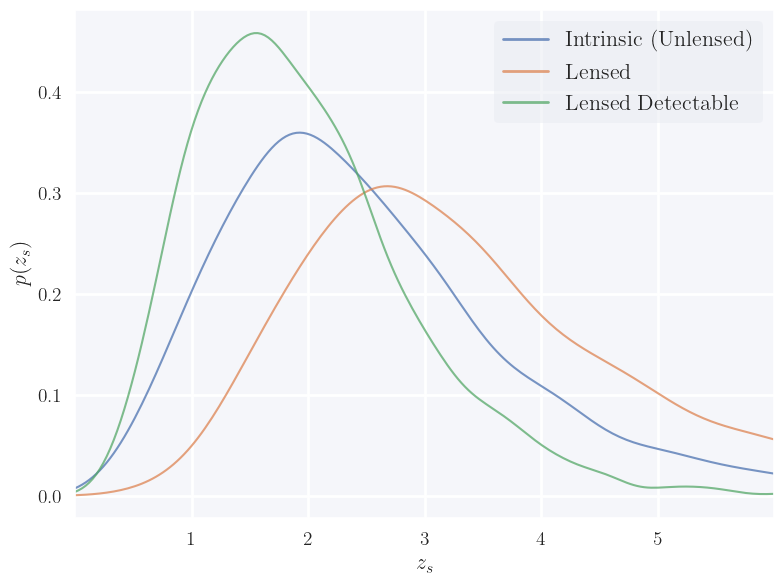

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# Reset + sns theme
mpl.rcParams.update(mpl.rcParamsDefault)

LIGHT_BG = "#F5F6FA"   # panel background (very light)
LEG_BG   = "#E9EBF2"   # legend background (slightly darker so it shows)

sns.set_theme(
    style="darkgrid",
    context="notebook",
    rc={
        "axes.facecolor": LIGHT_BG,
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.color": "white",
        "grid.linestyle": "-",
        "grid.linewidth": 2.0,  # wider gridlines
        "grid.alpha": 1.0,
        "axes.axisbelow": True,
    }
)

# If you want LaTeX + serif, keep it here
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "custom",
    "savefig.dpi": 300,
    "axes.labelsize": 16,      # axis label size
    "xtick.labelsize": 14,     # x tick label size
    "ytick.labelsize": 14,     # y tick label size
    "legend.fontsize": 16,     # legend text size
    "legend.title_fontsize": 17, # legend title size
    "axes.titlesize": 18       # title size
})

fig, ax1 = plt.subplots(figsize=(8, 6))

# --- y-axis: PDF p(z_s) ---
ax1.set_xlabel(r"$z_s$", fontsize=16)
ax1.set_ylabel(r"$p(z_s)$", fontsize=16)

# KDE making
from scipy.stats import gaussian_kde

pzs = unlensed_param['zs']
kde_zs = gaussian_kde(pzs)
pzs_sl = lensed_param['zs']
kde_zs_sl = gaussian_kde(pzs_sl)
pzs_sl_detectable = lensed_param_detectable['zs']
kde_zs_sl_detectable = gaussian_kde(pzs_sl_detectable)

zs = np.linspace(0.001, 6.0-0.001, 200)
ax1.plot(zs, kde_zs(zs), color="C0", linestyle="-",  alpha=0.75, label="Intrinsic (Unlensed)")
ax1.plot(zs, kde_zs_sl(zs), color="C1", linestyle="-",  alpha=0.75, label="Lensed")
ax1.plot(zs, kde_zs_sl_detectable(zs), color="C2", linestyle="-",  alpha=0.75, label="Lensed Detectable")

ax1.tick_params(axis="y", labelsize=14)
ax1.tick_params(axis="x", labelsize=14)
ax1.set_xlim(0.001, 6.0-0.001)
# Let matplotlib auto-scale the y-axis to fit KDE values


# Keep background + white grid consistent (twin axes can override)
ax1.set_facecolor(LIGHT_BG)
ax1.grid(True, color="white", linewidth=2.0, alpha=1.0)  # wider gridlines

leg1 = ax1.legend(loc="upper right", handlelength=2, frameon=True, fontsize=16, title_fontsize=17)
for h in leg1.get_lines():
    h.set_linewidth(2.0)
f1 = leg1.get_frame()
f1.set_facecolor(LEG_BG)
f1.set_edgecolor("none")
f1.set_linewidth(0.0)
f1.set_alpha(0.5)


# plt.title(r"PDF of source redshift $p(z_s)$", fontsize=18)
fig.tight_layout()

# If legends are near edges, include them to avoid clipping
fig.savefig(
    "pdf_of_redshifts_lensed.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


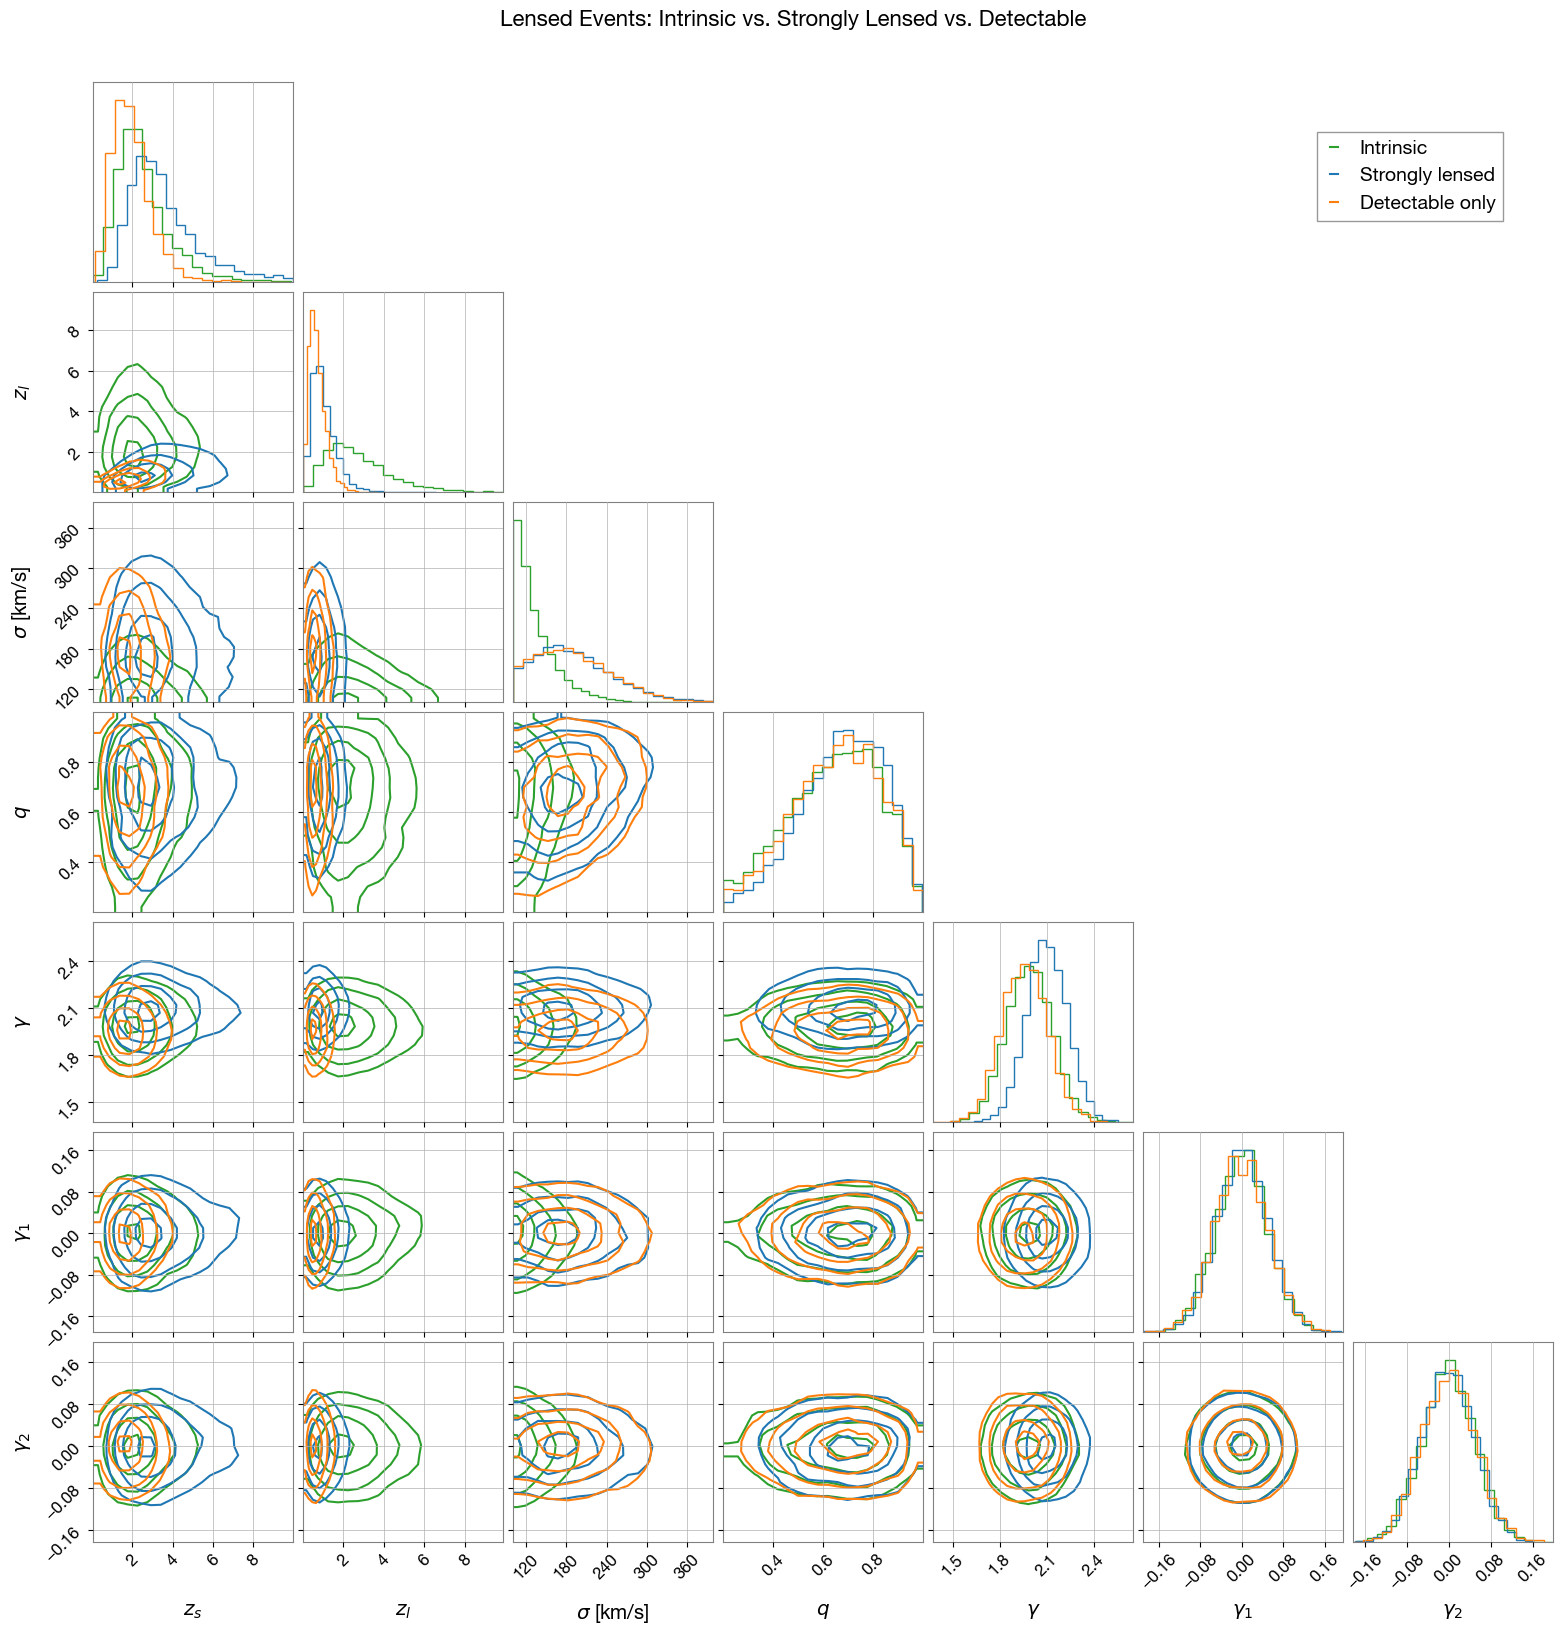

In [2]:
import corner
import matplotlib.lines as mlines

# Lensing-specific parameters to compare
param_names = ['zs', 'zl', 'sigma', 'q', 'gamma', 'gamma1', 'gamma2']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]', '$q$', r'$\gamma$', r'$\gamma_1$', r'$\gamma_2$']

size = min(5000, len(lensed_param_detectable[param_names[0]]), len(lensed_param_intrinsic[param_names[0]]), len(lensed_param[param_names[0]]))

# Prepare data for corner plot
idx = np.random.choice(len(lensed_param_intrinsic[param_names[0]]), size=size, replace=False)
samples_intrinsic = np.stack([lensed_param_intrinsic[p][idx] for p in param_names], axis=1)

idx = np.random.choice(len(lensed_param[param_names[0]]), size=size, replace=False)
samples_all = np.stack([lensed_param[p][idx] for p in param_names], axis=1)

idx = np.random.choice(len(lensed_param_detectable[param_names[0]]), size=size, replace=False)
samples_detectable = np.stack([lensed_param_detectable[p][idx] for p in param_names], axis=1)

# Create corner plot for intrinsic events
fig = corner.corner(
    samples_intrinsic, 
    labels=labels, 
    color='C2', 
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Overlay strongly lensed events
corner.corner(
    samples_all, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Overlay detectable events
corner.corner(
    samples_detectable, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    fig=fig, 
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Add legend
green_line = mlines.Line2D([], [], color='C2', label='Intrinsic')
blue_line = mlines.Line2D([], [], color='C0', label='Strongly lensed')
orange_line = mlines.Line2D([], [], color='C1', label='Detectable only')
fig.legend(handles=[green_line, blue_line, orange_line], loc='upper right', 
           bbox_to_anchor=(0.95, 0.95), fontsize=14)
fig.suptitle('Lensed Events: Intrinsic vs. Strongly Lensed vs. Detectable', fontsize=16, y=1.02)

plt.show()

size : 5000


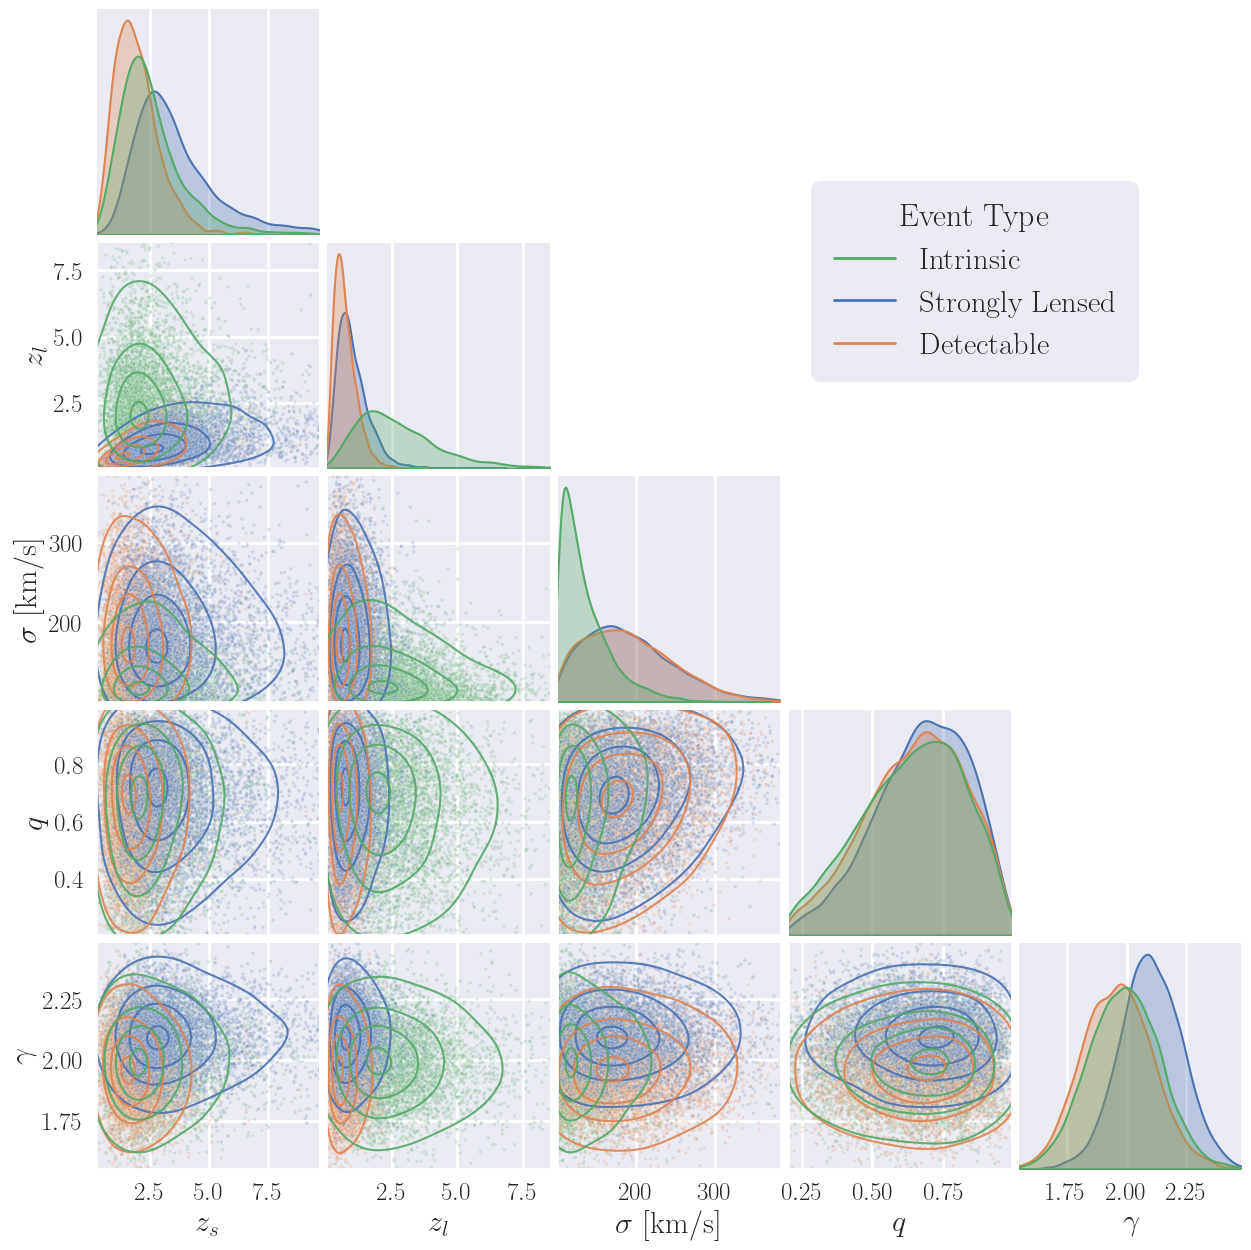

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# Reset to defaults (optional but good if you've been tweaking rcParams a lot)
mpl.rcParams.update(mpl.rcParamsDefault)
LIGHT_BG = "#EAEAF2"

# --- Seaborn grey background + white grid ---
sns.set_theme(
    style="darkgrid",   # grey background
    context="notebook",
    rc={
        # background
        "axes.facecolor": LIGHT_BG,   # seaborn-like grey
        "figure.facecolor": "white",
        # grid (white lines)
        "axes.grid": True,
        "grid.color": "white",
        "grid.linestyle": "-",
        "grid.linewidth": 2.0,
        "grid.alpha": 1.0,
        # keep grid behind artists
        "axes.axisbelow": True,
        # ticks (optional, helps readability on grey bg)
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "custom",
    "savefig.dpi": 150,
})

# Parameters to compare
param_names = ['zs', 'zl', 'sigma', 'q', 'gamma']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]', '$q$', r'$\gamma$']

size = min(5000, len(lensed_param_detectable[param_names[0]]), len(lensed_param_intrinsic[param_names[0]]), len(lensed_param[param_names[0]]))

# Create DataFrames
indices = np.random.choice(len(lensed_param_intrinsic[param_names[0]]), size=size, replace=False)
df_intrinsic = pd.DataFrame({label: lensed_param_intrinsic[name][indices] for name, label in zip(param_names, labels)})
df_intrinsic['Event Type'] = 'Intrinsic'


indices = np.random.choice(len(lensed_param_detectable[param_names[0]]), size=size, replace=False)
df_detectable = pd.DataFrame({label: lensed_param_detectable[name][indices] for name, label in zip(param_names, labels)})
df_detectable['Event Type'] = 'Detectable'

print(f"size : {size}")

indices = np.random.choice(len(lensed_param[param_names[0]]), size=size, replace=False)
df_all = pd.DataFrame({label: lensed_param[name][indices] for name, label in zip(param_names, labels)})
df_all['Event Type'] = 'Strongly Lensed'

# Combine DataFrames
df_combined = pd.concat([df_intrinsic, df_detectable, df_all], ignore_index=True)

# Calculate 1st and 99th percentiles for each parameter to set limits
percentile_limits = {}
for label in labels:
    lower = np.percentile(df_combined[label], 0.1)
    upper = np.percentile(df_combined[label], 99.9)
    # Add some padding (1% of range)
    range_pad = (upper - lower) * 0.0
    percentile_limits[label] = (lower - range_pad, upper + range_pad)

# Create pairplot with both scatter and contour (KDE) for 2D plots
# First, make the scatter pairplot with smaller point size
pairplot_scatter = sns.pairplot(
    df_combined,
    hue='Event Type',
    palette={'Strongly Lensed': 'C0', 'Detectable': 'C1', 'Intrinsic': 'C2'},
    corner=True,
    kind='scatter',
    plot_kws=dict(marker=".", alpha=0.2, s=25),  # s=25 for smaller points
    diag_kind='kde',
    diag_kws={'alpha': 0.3, 'linewidth': 1.5}
)

contour_levels=np.sort(np.array([10, 40, 68, 95])/100)

# Overlay KDE contours on the lower triangle
for i, row_label in enumerate(labels):
    for j, col_label in enumerate(labels):
        if i > j:
            ax = pairplot_scatter.axes[i, j]
            for event_type, color in zip(['Strongly Lensed', 'Detectable', 'Intrinsic'], ['C0', 'C1', 'C2']):
                subset = df_combined[df_combined['Event Type'] == event_type]
                sns.kdeplot(
                    x=subset[col_label],
                    y=subset[row_label],
                    ax=ax,
                    levels=contour_levels,
                    color=color,
                    alpha=0.9,
                    linewidths=1.5,
                    bw_adjust=1.8,
                    fill=False
                )
            ax.set_xlim(percentile_limits[col_label])
            ax.set_ylim(percentile_limits[row_label])
        elif i == j:
            ax = pairplot_scatter.axes[i, j]
            ax.set_xlim(percentile_limits[row_label])

# Remove the default legend created by seaborn
if pairplot_scatter._legend is not None:
    pairplot_scatter._legend.remove()

# Custom legend with line handles instead of points
line_handles = [
    Line2D([0], [0], color='C2', lw=2, label='Intrinsic'),
    Line2D([0], [0], color='C0', lw=2, label='Strongly Lensed'),
    Line2D([0], [0], color='C1', lw=2, label='Detectable'),
]
leg = pairplot_scatter.fig.legend(
    handles=line_handles,
    title="Event Type", 
    loc='upper right',
    bbox_to_anchor=(0.80, 0.85),
    fontsize=22,
    title_fontsize=23,
    frameon=True
)
leg.get_title().set_weight("bold")
frame = leg.get_frame()
frame.set_facecolor("#EAEAF2")
frame.set_edgecolor("none")
frame.set_linewidth(0.6)
frame.set_alpha(1.0)
frame.set_boxstyle("round,pad=0.35")

# Increase axis label font size
for ax in pairplot_scatter.fig.axes:
    ax.set_facecolor(LIGHT_BG)
    # ax.grid(True, color="black", linestyle='--', linewidth=1.0, alpha=0.1)
    ax.xaxis.label.set_size(22)
    ax.yaxis.label.set_size(22)
    ax.tick_params(labelsize=18)

pairplot_scatter.fig.savefig("Lensed_Events.png", bbox_inches="tight", dpi=150)
plt.show()
# time: 29.9s